**Movie_Recommendation_System**

# *🔹 1. Install Dependencies*

In [ ]:
#!pip install plotly

# *🔹 2. Import Libraries*

In [ ]:
#!pip install 'numpy<2' --force-reinstall
#!pip install scikit-surprise --force-reinstall
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import accuracy

import pickle

# *🔹 3. Load Dataset*

In [ ]:
movies = pd.read_csv('/content/movies.dat', sep='::', engine='python', header=None, names=['movieId', 'title', 'genres'], encoding='latin1')
ratings = pd.read_csv('/content/ratings.dat', sep='::', engine='python', header=None, names=['userId', 'movieId', 'rating', 'timestamp'], encoding='latin1')

print(movies.head())
print(ratings.head())

   movieId                               title                        genres
0        1                    Toy Story (1995)   Animation|Children's|Comedy
1        2                      Jumanji (1995)  Adventure|Children's|Fantasy
2        3             Grumpier Old Men (1995)                Comedy|Romance
3        4            Waiting to Exhale (1995)                  Comedy|Drama
4        5  Father of the Bride Part II (1995)                        Comedy
   userId  movieId  rating  timestamp
0       1     1193       5  978300760
1       1      661       3  978302109
2       1      914       3  978301968
3       1     3408       4  978300275
4       1     2355       5  978824291


# *🔹 4. Data Preprocessing*

In [ ]:
# Merge datasets
df = ratings.merge(movies, on='movieId')

# Handle missing values
df.dropna(inplace=True)

# Convert genres to string
df['genres'] = df['genres'].str.replace('|', ' ')

# ***EDA***

title
Ulysses (Ulisse) (1954)                      5.0
Lured (1947)                                 5.0
Follow the Bitch (1998)                      5.0
Bittersweet Motel (2000)                     5.0
Song of Freedom (1936)                       5.0
One Little Indian (1973)                     5.0
Smashing Time (1967)                         5.0
Schlafes Bruder (Brother of Sleep) (1995)    5.0
Gate of Heavenly Peace, The (1995)           5.0
Baby, The (1973)                             5.0
Name: rating, dtype: float64


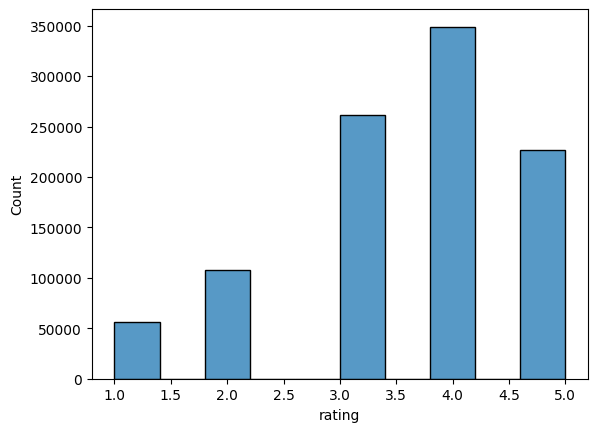

In [ ]:
# Top rated movies
top_movies = df.groupby('title')['rating'].mean().sort_values(ascending=False).head(10)
print(top_movies)

# Ratings distribution
sns.histplot(df['rating'], bins=10)
plt.show()

# Plotly visualization
fig = px.histogram(df, x="rating", nbins=10, title="Ratings Distribution")
fig.show()

# *🔹 6. Content-Based Filtering*

In [ ]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

# *Recommendation Function*

In [ ]:
def content_recommend(title, cosine_sim=cosine_sim):
    idx = indices[title]
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:11]
    movie_indices = [i[0] for i in scores]
    return movies['title'].iloc[movie_indices]

# *🔹 7. Collaborative Filtering (SVD)*

In [ ]:
reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(ratings[['userId','movieId','rating']], reader)

trainset, testset = train_test_split(data, test_size=0.2)

model = SVD()
model.fit(trainset)

predictions = model.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8767


0.8767168832312956

# *🔹 8. Hybrid Model*

In [ ]:
def hybrid_recommend(user_id, title):
    content = content_recommend(title)

    movie_ids = movies[movies['title'].isin(content)]['movieId']

    scores = []
    for m in movie_ids:
        pred = model.predict(user_id, m)
        scores.append((m, pred.est))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)[:10]

    return [movies[movies['movieId']==i]['title'].values[0] for i,_ in scores]

# *🔹 9. Save Model*

In [ ]:
pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(cosine_sim, open('cosine.pkl', 'wb'))
pickle.dump(movies, open('movies.pkl', 'wb'))

In [ ]:
from google.colab import files

files.download('model.pkl')
files.download('cosine.pkl')
files.download('movies.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>